In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
from functools import partial

import torch
import torch.nn as nn
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything

from src.models_mae5 import GeoMaskedAutoEncoder
from src.dataloaders import GeoDataloader

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
import pathlib
data_path = pathlib.Path("./data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))
len(files)

3000

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import torch

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.utils import _log_api_usage_once
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm

In [4]:
class LitProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = tqdm(            
            disable=True,            
        )
        return bar

# Add a logger for metrics and checkpoints
csv_logger = CSVLogger(
    save_dir='',
    name='logs'
)

In [9]:
class GeoMAE(LightningModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        self.model = GeoMaskedAutoEncoder(*args, **kwargs)

    def forward(self, batch):
        return self.model.forward(batch[0], batch[1])

    def training_step(self, batch, batch_idx):
        loss = self.model.forward_loss(*batch)[0]
        # log training loss
        self.log(
            "train_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.model.forward_loss(*batch)[0]
        # log validation loss
        self.log(
            "val_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss

    def test_step(self, batch, batch_idx):
        loss = self.model.forward_loss(*batch)[0]
        # log test loss
        self.log(
            "test_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": ReduceLROnPlateau(optimizer),
                "patience": 10,
                "interval": "epoch",
                "monitor": "val_loss",
                "frequency": 1,
            },
        }

In [10]:
GeoMaskedAutoEncoder?

Init signature:
GeoMaskedAutoEncoder(
    img_size: int = 256,
    patch_size: int = 16,
    in_chans: int = 3,
    embed_dim: int = 768,
    depth: int = 12,
    num_heads: int = 12,
    decoder_embed_dim: int = 512,
    decoder_depth: int = 8,
    decoder_num_heads: int = 8,
    mlp_ratio: float = 4.0,
    qkv_bias: bool = False,
    qk_scale: float = None,
    drop_rate: float = 0.0,
    attn_drop_rate: float = 0.0,
    drop_path_rate: float = 0.0,
    norm_layer: torch.nn.modules.module.Module = <class 'torch.nn.modules.normalization.LayerNorm'>,
    block_layers: torch.nn.modules.module.Module = <class 'src.models_mae5.Block'>,
    Patch_layer: torch.nn.modules.module.Module = <class 'timm.layers.patch_embed.PatchEmbed'>,
    act_layer: torch.nn.modules.module.Module = <class 'torch.nn.modules.activation.GELU'>,
    Attention_block: torch.nn.modules.module.Module = <class 'src.models_mae5.GeoRoPEAttention'>,
    Mlp_block: torch.nn.modules.module.Module = <class 'timm.layers.mlp.M

In [11]:
_ = seed_everything(42)

dl = GeoDataloader(32, files)

model = GeoMAE(
    img_size=256, 
    patch_size=16, 
    embed_dim=1024, 
    depth=8,
    num_heads=8,
    decoder_depth=4, 
    decoder_num_heads=8,
    mlp_ratio=2.,
)


Seed set to 42


In [12]:
# Initialize the trainer
trainer = Trainer(
    max_epochs=10,
    callbacks=[LitProgressBar()],
    logger=csv_logger,
    accelerator="auto",
)

trainer.fit(model, dl)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/core/optimizer.py:259: Found unsupported keys in the lr scheduler dict: {'patience'}. HINT: remove them from the output of `configure_optimizers`.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GeoMaskedAutoEncoder │ 77.3 M │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 77.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 77.3 M                                                                                               
Total estimated model params size (MB): 309                                                                        
Modules in train mode: 228                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                                                                          | 0/? [00:00<?, ?it/s]

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 9: 100%|█| 66/66 [02:08<00:00,  0.51it/s, v_num=0, train_loss_step=0.0126, val_loss_step=0.0103, val_loss_epoch=0.0114, trai

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|█| 66/66 [02:09<00:00,  0.51it/s, v_num=0, train_loss_step=0.0126, val_loss_step=0.0103, val_loss_epoch=0.0114, trai


In [13]:
_ = model.eval()

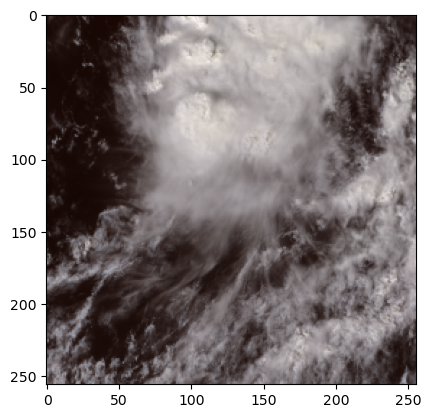

In [14]:
plt.imshow(dl.train_dataset[300][0].transpose(1,2,0))

In [25]:
model.model.forward(
        torch.tensor(dl.train_dataset[300][0][np.newaxis]), 
        torch.tensor(dl.train_dataset[300][1][np.newaxis]), 
        mask_ratio=0.75
    )[0].shape

torch.Size([1, 256, 768])

In [34]:
test = model.model.unpatchify(
    model.model.forward(
        torch.tensor(dl.train_dataset[300][0][np.newaxis]), 
        torch.tensor(dl.train_dataset[300][1][np.newaxis]), 
        mask_ratio=0.75
    )[0]
).detach().numpy()[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5376081..2.2373765].


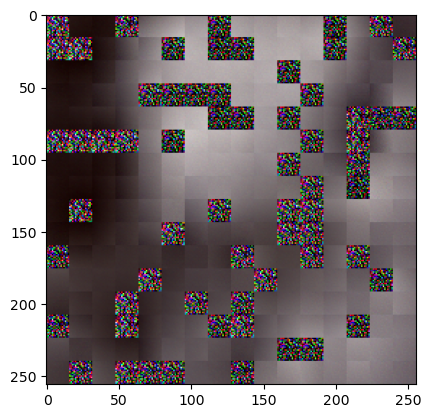

In [35]:
plt.imshow(test.transpose(1,2,0))